## Intro

#### Install and imports

In [32]:
#pip install scikit-learn

In [46]:
import os
import pandas as pd
import sklearn
from sklearn.metrics import mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt 

#### Variables to be analyzed

In [77]:
variables = ['Size', 'PdI', 'ZP', 'EE', 'DL']
variables_conv = ['Distance', 'ZP', 'EE', 'DL']

#### *Monte Carlo* parameters

In [35]:
n_iterations = 200 # numbner of iterations (simulations) for each noise level 
sigmas = [0.02, 0.05, 0.1] # Noise levels as a percentage values (e.g., 2%, 5%, 10%)
epsilon = 1e-8

## Round 1 WITHOUT CONVOLUTION 

### Route to the csv file and read it

In [63]:
#Route to the file

BASE_DIR = os.getcwd()

file_path = os.path.join(
    BASE_DIR,
    "Pred_obs_R1.csv",
)

#Read the CSV file
DE_round1 = pd.read_csv(file_path, sep=";")
DE_round1 = DE_round1.dropna(how="all") # Remove rows where all values are NaN

### Metrics calculations (without "noise")

In [72]:
mae_results1 =  []
mre_results1 = []

for var in variables:
    
    y_obs = pd.to_numeric(DE_round1[f"{var}_obs"], errors='coerce')
    y_pred = pd.to_numeric(DE_round1[f"{var}_pred"], errors='coerce')

    df_temp = pd.DataFrame({"obs": y_obs, "pred": y_pred}).dropna()

    y_obs = df_temp["obs"].values
    y_pred = df_temp["pred"].values

    #MAE calculation
    mae = mean_absolute_error(y_obs, y_pred)
    
    #MRE calculation
    mre = np.mean(np.abs((y_obs - y_pred) / (np.abs(y_obs) + epsilon))) * 100

    mae_results1.append([var, mae])
    mre_results1.append([var, mre])

#Create dataframes for MAE and MRE results
mae_df1 = pd.DataFrame(mae_results1, columns=["Variable", "MAE"]).round(2)
mre_df1 = pd.DataFrame(mre_results1, columns=["Variable", "MRE_%"]).round(2)    

#Merge metrics dataframes
metrics_wo_noiseR1 = pd.merge(mae_df1, mre_df1, on="Variable")

#### Show and print results

In [65]:
#Show results
print("\nMetrics without noise R1:")
print(metrics_wo_noiseR1)

# Save results
output_path = os.path.join(BASE_DIR, "Metrics_wo_noiseR1.csv")
metrics_wo_noiseR1.to_csv(output_path, index=False)


Metrics without noise R1:
  Variable    MAE   MRE_%
0     Size  61.64  123.50
1      PdI   0.04   38.10
2       ZP   0.77  203.70
3       EE  32.12   46.02
4       DL   7.32  238.40


### Metrics calculations (with "noise" *Monte Carlo*)

In [66]:
mae_noise_results = []
mre_noise_results = []

for sigma_factor in sigmas:
    
    for var in variables:

        #Convert data to numeric and drop NaN values  
        y_obs = pd.to_numeric(DE_round1[f"{var}_obs"], errors='coerce')
        y_pred = pd.to_numeric(DE_round1[f"{var}_pred"], errors='coerce')

        df_temp = pd.DataFrame({"obs": y_obs, "pred": y_pred}).dropna()

        y_obs = df_temp["obs"].values
        y_pred = df_temp["pred"].values

        sigma = sigma_factor * np.mean(np.abs(y_obs))

        mae_list = []
        mre_list = [] 

        #Monte Carlo simulation
        for i in range(n_iterations):

            noise = np.random.normal(0, sigma, size=len(y_obs))
            y_noisy = y_obs + noise

            #MAE
            mae = mean_absolute_error(y_noisy, y_pred)
            mae_list.append(mae)

            # MRE (%)
            mre = np.mean(np.abs((y_noisy - y_pred) / (np.abs(y_noisy) + epsilon))) * 100
            mre_list.append(mre)

        mae_noise_results.append([
            var, #analyzed variable
            sigma_factor, #noise level
            np.mean(mae_list), #Mean MAE
            np.std(mae_list) #Standard deviation of MAE
        ])

        mre_noise_results.append([
            var, #analyzed variable
            sigma_factor, #noise level
            np.mean(mre_list), #Mean MRE
            np.std(mre_list)  #Standard deviation of MRE
        ])

#Create dataframes for MAE and MRE results with noise
##MAE dataframe
mae_noise_df = pd.DataFrame(
    mae_noise_results,
    columns=["Variable", "Sigma_%", "MAE_mean", "MAE_std"]
).round(2)

##MRE dataframe
mre_noise_df = pd.DataFrame(
    mre_noise_results,
    columns=["Variable", "Sigma_%", "MRE_mean", "MRE_std"]
).round(2)

#Show the sigma results in percentage format
mae_noise_df["Sigma_%"] = (mae_noise_df["Sigma_%"] * 100).astype(int)
mre_noise_df["Sigma_%"] = (mre_noise_df["Sigma_%"] * 100).astype(int)

#Merge MAE and MRE dataframes
metrics_noiseR1 = pd.merge(mae_noise_df, mre_noise_df, on=["Variable", "Sigma_%"])

#### Show and print results

In [67]:
print("\nMetrics with noise R1 (different levels):")
print(metrics_noiseR1)

output_path = os.path.join(BASE_DIR, "Metrics_noise_R1.csv")
metrics_noiseR1.to_csv(output_path, index=False)


Metrics with noise R1 (different levels):
   Variable  Sigma_%  MAE_mean  MAE_std  MRE_mean  MRE_std
0      Size        2     61.63     0.48    124.07     5.97
1       PdI        2      0.04     0.00     38.20     1.21
2        ZP        2      0.77     0.00    203.90     1.05
3        EE        2     32.09     0.44     46.01     0.94
4        DL        2      7.32     0.02    238.60     2.14
5      Size        5     61.60     1.21    126.06    16.32
6       PdI        5      0.04     0.00     38.86     2.98
7        ZP        5      0.77     0.01    204.17     2.80
8        EE        5     32.20     1.16     46.49     2.51
9        DL        5      7.32     0.05    238.91     6.05
10     Size       10     61.59     2.36    212.40   589.66
11      PdI       10      0.04     0.00     41.06     6.81
12       ZP       10      0.77     0.01    205.77     5.51
13       EE       10     32.37     2.18     47.76     4.92
14       DL       10      7.31     0.09    240.50    11.11


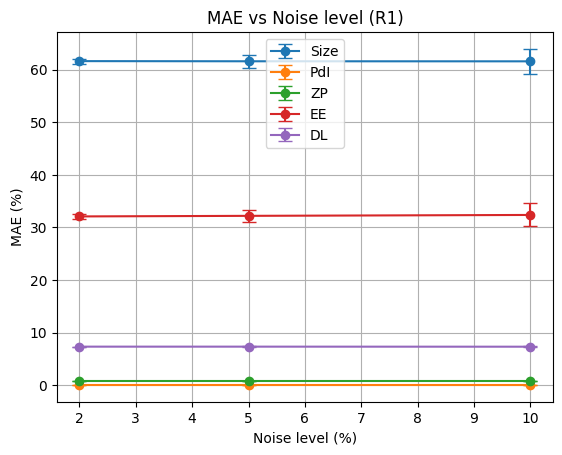

In [68]:
for var in variables:
    df_plot = metrics_noiseR1[metrics_noiseR1["Variable"] == var]

    plt.errorbar(
        df_plot["Sigma_%"],
        df_plot["MAE_mean"],
        yerr=df_plot["MAE_std"],
        marker='o',
        capsize=5,
        label=var
    )

plt.xlabel("Noise level (%)")
plt.ylabel("MAE (%)")
plt.title("MAE vs Noise level (R1)")
plt.legend()
plt.grid(True)
plt.show()

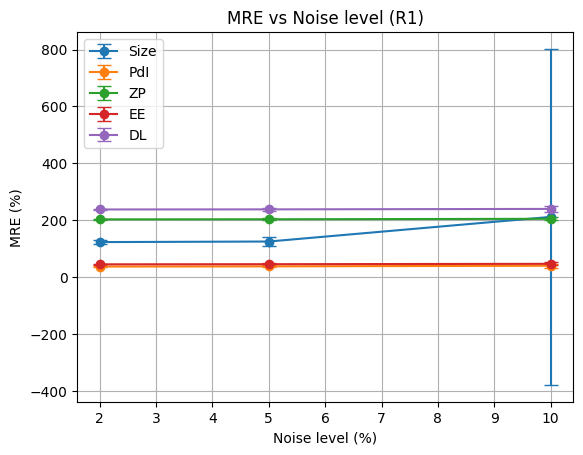

In [69]:
for var in variables:
    df_plot = metrics_noiseR1[metrics_noiseR1["Variable"] == var]

    plt.errorbar(
        df_plot["Sigma_%"],
        df_plot["MRE_mean"],
        yerr=df_plot["MRE_std"],
        marker='o',
        capsize=5,
        label=var
    )

plt.xlabel("Noise level (%)")
plt.ylabel("MRE (%)")
plt.title("MRE vs Noise level (R1)")
plt.legend()
plt.grid(True)
plt.show()

## Round 1 WITH CONVOLUTION 

### Route to the csv file and read it 

In [78]:
#Route to the file

BASE_DIR = os.getcwd()

file_path = os.path.join(
    BASE_DIR,
    "Pred_obs_w_conv_R1.csv",
)

#Read the CSV file
DE_round1_conv = pd.read_csv(file_path, sep=";")
DE_round1_conv = DE_round1_conv.dropna(how="all") # Remove rows where all values are NaN

### Metrics calculations (without "noise")

In [84]:
mae_results1_conv =  []
mre_results1_conv = []

for var in variables_conv:
    
    y_obs = pd.to_numeric(DE_round1_conv[f"{var}_obs"], errors='coerce')
    y_pred = pd.to_numeric(DE_round1_conv[f"{var}_pred"], errors='coerce')

    df_temp = pd.DataFrame({"obs": y_obs, "pred": y_pred}).dropna()

    y_obs = df_temp["obs"].values
    y_pred = df_temp["pred"].values

    #MAE calculation
    mae = mean_absolute_error(y_obs, y_pred)
    
    #MRE calculation
    mre = np.mean(np.abs((y_obs - y_pred) / (np.abs(y_obs) + epsilon))) * 100

    mae_results1_conv.append([var, mae])
    mre_results1_conv.append([var, mre])

#Create dataframes for MAE and MRE results
mae_df1_conv = pd.DataFrame(mae_results1_conv, columns=["Variable", "MAE"]).round(2)
mre_df1_conv = pd.DataFrame(mre_results1_conv, columns=["Variable", "MRE_%"]).round(2)    

#Merge metrics dataframes
metrics_wo_noise_conv_R1 = pd.merge(mae_df1_conv, mre_df1_conv, on="Variable")

#### Show and print results

In [86]:
#Show results
print("\nMetrics without noise R1 (with convolution):")
print(metrics_wo_noise_conv_R1)

# Save results
output_path = os.path.join(BASE_DIR, "Metrics_wo_noise_conv_R1.csv")
metrics_wo_noise_conv_R1.to_csv(output_path, index=False)


Metrics without noise R1 (with convolution):
   Variable    MAE    MRE_%
0  Distance   6.39  1399.72
1        ZP   0.58   122.50
2        EE  16.10   158.65
3        DL   1.35    77.91


### Metrics calculations (with "noise" *Monte Carlo*)

In [89]:
mae_noise_results = []
mre_noise_results = []

for sigma_factor in sigmas:
    
    for var in variables_conv:

        #Convert data to numeric and drop NaN values  
        y_obs = pd.to_numeric(DE_round1_conv[f"{var}_obs"], errors='coerce')
        y_pred = pd.to_numeric(DE_round1_conv[f"{var}_pred"], errors='coerce')

        df_temp = pd.DataFrame({"obs": y_obs, "pred": y_pred}).dropna()

        y_obs = df_temp["obs"].values
        y_pred = df_temp["pred"].values

        sigma = sigma_factor * np.mean(np.abs(y_obs))

        mae_list = []
        mre_list = [] 

        #Monte Carlo simulation
        for i in range(n_iterations):

            noise = np.random.normal(0, sigma, size=len(y_obs))
            y_noisy = y_obs + noise

            #MAE
            mae = mean_absolute_error(y_noisy, y_pred)
            mae_list.append(mae)

            # MRE (%)
            mre = np.mean(np.abs((y_noisy - y_pred) / (np.abs(y_noisy) + epsilon))) * 100
            mre_list.append(mre)

        mae_noise_results.append([
            var, #analyzed variable
            sigma_factor, #noise level
            np.mean(mae_list), #Mean MAE
            np.std(mae_list) #Standard deviation of MAE
        ])

        mre_noise_results.append([
            var, #analyzed variable
            sigma_factor, #noise level
            np.mean(mre_list), #Mean MRE
            np.std(mre_list)  #Standard deviation of MRE
        ])

#Create dataframes for MAE and MRE results with noise
##MAE dataframe
mae_noise_df = pd.DataFrame(
    mae_noise_results,
    columns=["Variable", "Sigma_%", "MAE_mean", "MAE_std"]
).round(2)

##MRE dataframe
mre_noise_df = pd.DataFrame(
    mre_noise_results,
    columns=["Variable", "Sigma_%", "MRE_mean", "MRE_std"]
).round(2)

#Show the sigma results in percentage format
mae_noise_df["Sigma_%"] = (mae_noise_df["Sigma_%"] * 100).astype(int)
mre_noise_df["Sigma_%"] = (mre_noise_df["Sigma_%"] * 100).astype(int)

#Merge MAE and MRE dataframes
metrics_noise_conv_R1 = pd.merge(mae_noise_df, mre_noise_df, on=["Variable", "Sigma_%"])

#### Show and print results

In [90]:
print("\nMetrics with noise R1 with convolution(different levels):")
print(metrics_noise_conv_R1)

output_path = os.path.join(BASE_DIR, "Metrics_noise_conv_R1.csv")
metrics_noise_conv_R1.to_csv(output_path, index=False)


Metrics with noise R1 with convolution(different levels):
    Variable  Sigma_%  MAE_mean  MAE_std  MRE_mean   MRE_std
0   Distance        2      6.39     0.03  10324.28  73038.34
1         ZP        2      0.58     0.01    126.23     12.91
2         EE        2     16.08     0.36   5004.08  63068.53
3         DL        2      1.35     0.02     78.22      3.84
4   Distance        5      6.39     0.07   8400.13  58570.02
5         ZP        5      0.58     0.02    219.90    491.73
6         EE        5     16.15     0.91    435.53   1153.22
7         DL        5      1.36     0.04     90.64     35.83
8   Distance       10      6.42     0.16   3237.71  15878.76
9         ZP       10      0.59     0.04    327.78   1324.49
10        EE       10     17.07     1.59    179.08    222.45
11        DL       10      1.38     0.08    111.57     61.70


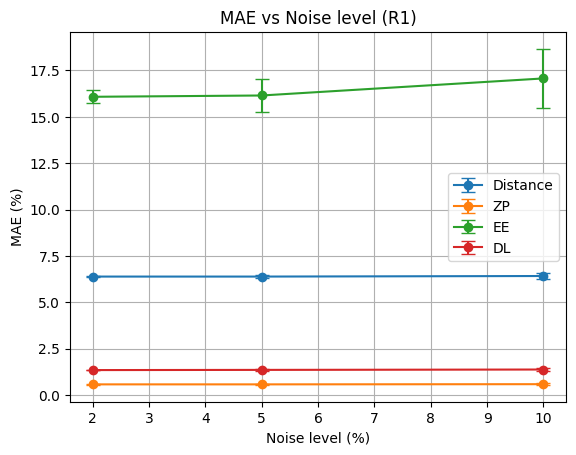

In [91]:
for var in variables_conv:
    df_plot = metrics_noise_conv_R1[metrics_noise_conv_R1["Variable"] == var]

    plt.errorbar(
        df_plot["Sigma_%"],
        df_plot["MAE_mean"],
        yerr=df_plot["MAE_std"],
        marker='o',
        capsize=5,
        label=var
    )

plt.xlabel("Noise level (%)")
plt.ylabel("MAE (%)")
plt.title("MAE vs Noise level (R1)")
plt.legend()
plt.grid(True)
plt.show()

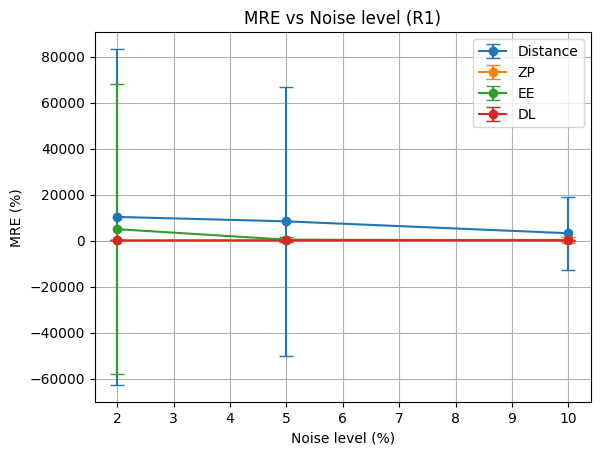

In [92]:
for var in variables_conv:
    df_plot = metrics_noise_conv_R1[metrics_noise_conv_R1["Variable"] == var]

    plt.errorbar(
        df_plot["Sigma_%"],
        df_plot["MRE_mean"],
        yerr=df_plot["MRE_std"],
        marker='o',
        capsize=5,
        label=var
    )

plt.xlabel("Noise level (%)")
plt.ylabel("MRE (%)")
plt.title("MRE vs Noise level (R1)")
plt.legend()
plt.grid(True)
plt.show()

## Comparation

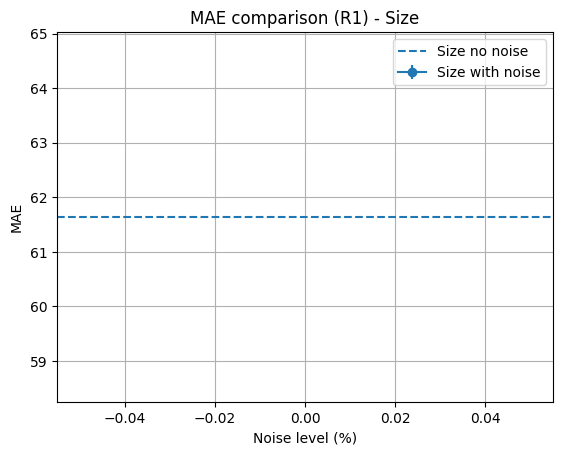

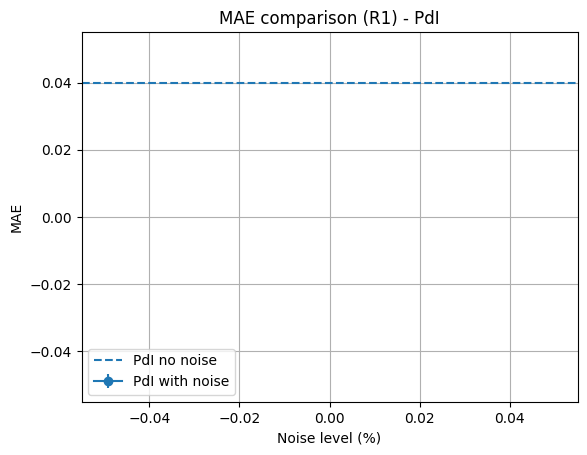

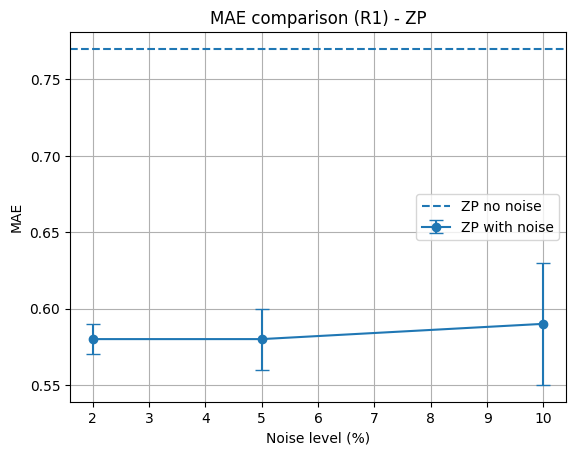

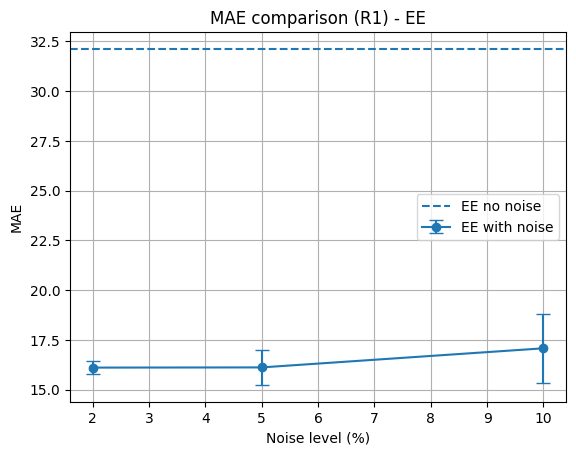

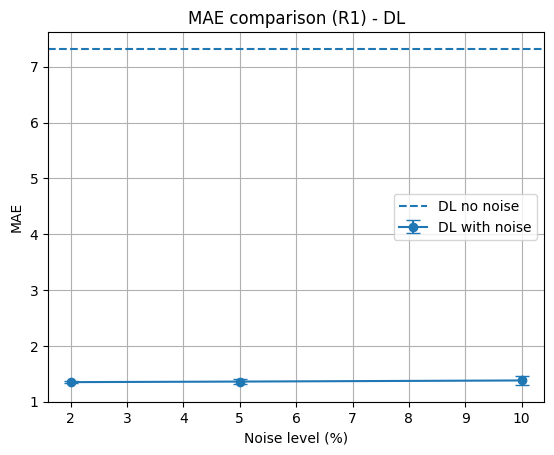

In [93]:
for var in variables:

    df_noise = metrics_noiseR1[metrics_noiseR1["Variable"] == var]
    df_base = metrics_wo_noiseR1[metrics_wo_noiseR1["Variable"] == var]

    mae_base = df_base["MAE"].values[0]

    # 🔵 con ruido
    plt.errorbar(
        df_noise["Sigma_%"],
        df_noise["MAE_mean"],
        yerr=df_noise["MAE_std"],
        marker='o',
        capsize=5,
        label=f"{var} with noise"
    )

    # 🔴 sin ruido (línea horizontal)
    plt.axhline(
        y=mae_base,
        linestyle='--',
        label=f"{var} no noise"
    )

    plt.xlabel("Noise level (%)")
    plt.ylabel("MAE")
    plt.title(f"MAE comparison (R1) - {var}")
    plt.legend()
    plt.grid(True)

    plt.show()

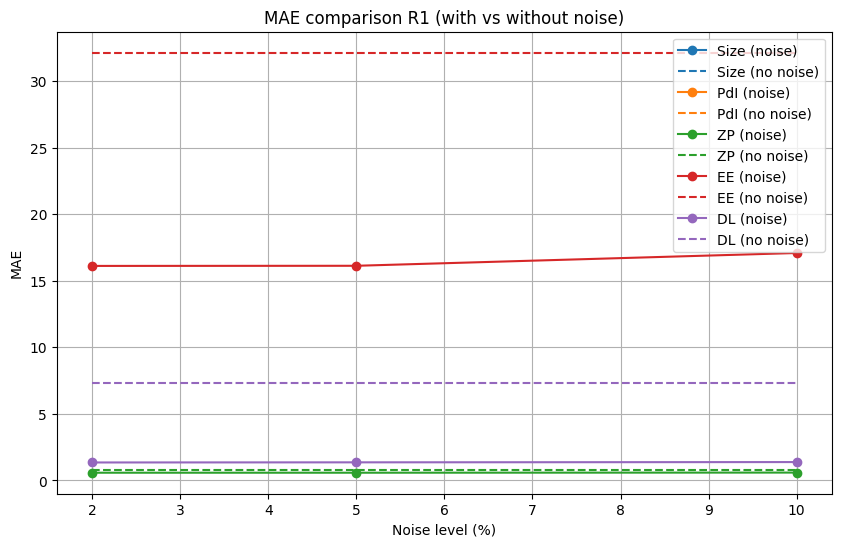

In [94]:
plt.figure(figsize=(10,6))

# 🎨 colores para cada variable
colors = {
    "Size": "#1f77b4",
    "PdI": "#ff7f0e",
    "ZP": "#2ca02c",
    "EE": "#d62728",
    "DL": "#9467bd"
}

for var in variables:

    df_noise = metrics_noiseR1[metrics_noiseR1["Variable"] == var]
    df_base = metrics_wo_noiseR1[metrics_wo_noiseR1["Variable"] == var]

    mae_base = df_base["MAE"].values[0]

    # ✅ con ruido (línea sólida)
    plt.plot(
        df_noise["Sigma_%"],
        df_noise["MAE_mean"],
        marker='o',
        linestyle='-',
        color=colors[var],
        label=f"{var} (noise)"
    )

    # ✅ sin ruido (línea discontinua)
    plt.hlines(
        y=mae_base,
        xmin=df_noise["Sigma_%"].min(),
        xmax=df_noise["Sigma_%"].max(),
        linestyles='--',
        color=colors[var],
        label=f"{var} (no noise)"
    )

plt.xlabel("Noise level (%)")
plt.ylabel("MAE")
plt.title("MAE comparison R1 (with vs without noise)")
plt.legend()
plt.grid(True)

plt.show()


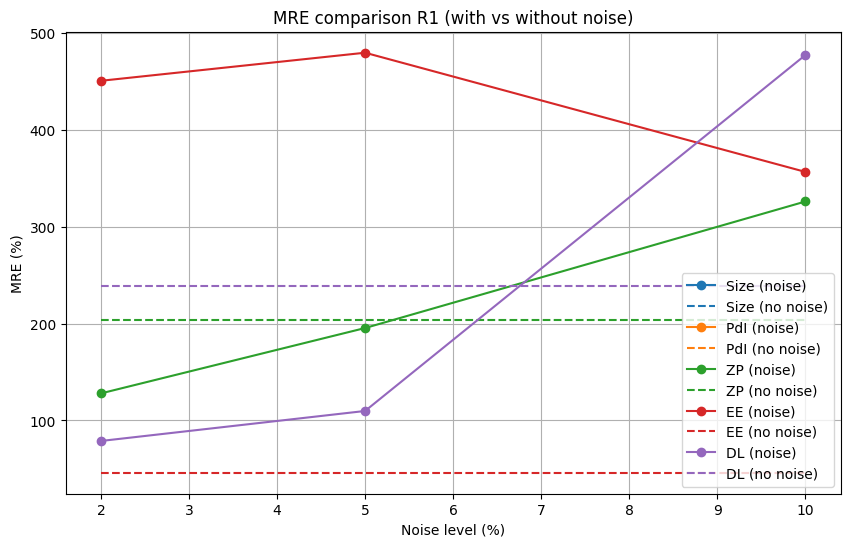

In [95]:
plt.figure(figsize=(10,6))

for var in variables:

    df_noise = metrics_noiseR1[metrics_noiseR1["Variable"] == var]
    df_base = metrics_wo_noiseR1[metrics_wo_noiseR1["Variable"] == var]

    mre_base = df_base["MRE_%"].values[0]

    # ✅ con ruido
    plt.plot(
        df_noise["Sigma_%"],
        df_noise["MRE_mean"],
        marker='o',
        linestyle='-',
        color=colors[var],
        label=f"{var} (noise)"
    )

    # ✅ sin ruido
    plt.hlines(
        y=mre_base,
        xmin=df_noise["Sigma_%"].min(),
        xmax=df_noise["Sigma_%"].max(),
        linestyles='--',
        color=colors[var],
        label=f"{var} (no noise)"
    )

plt.xlabel("Noise level (%)")
plt.ylabel("MRE (%)")
plt.title("MRE comparison R1 (with vs without noise)")
plt.legend()
plt.grid(True)

plt.show()


In [96]:
variables_common = ['ZP', 'EE', 'DL']

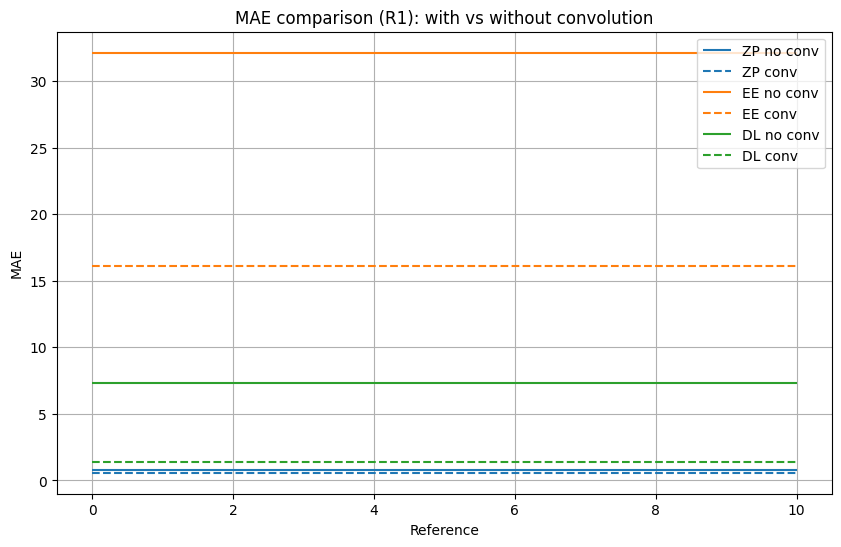

In [97]:
plt.figure(figsize=(10,6))

variables_common = ['ZP', 'EE', 'DL']

colors = {
    "ZP": "#1f77b4",
    "EE": "#ff7f0e",
    "DL": "#2ca02c"
}

for var in variables_common:

    # 🔵 sin convolución
    df_no = metrics_wo_noiseR1[metrics_wo_noiseR1["Variable"] == var]
    mae_no = df_no["MAE"].values[0]

    # 🔴 con convolución
    df_conv = metrics_wo_noise_conv_R1[metrics_wo_noise_conv_R1["Variable"] == var]
    mae_conv = df_conv["MAE"].values[0]

    # línea horizontal sin conv
    plt.hlines(
        y=mae_no,
        xmin=0,
        xmax=10,
        linestyle='-',
        color=colors[var],
        label=f"{var} no conv"
    )

    # línea horizontal con conv
    plt.hlines(
        y=mae_conv,
        xmin=0,
        xmax=10,
        linestyle='--',
        color=colors[var],
        label=f"{var} conv"
    )

plt.xlabel("Reference")
plt.ylabel("MAE")
plt.title("MAE comparison (R1): with vs without convolution")
plt.legend()
plt.grid(True)

plt.show()

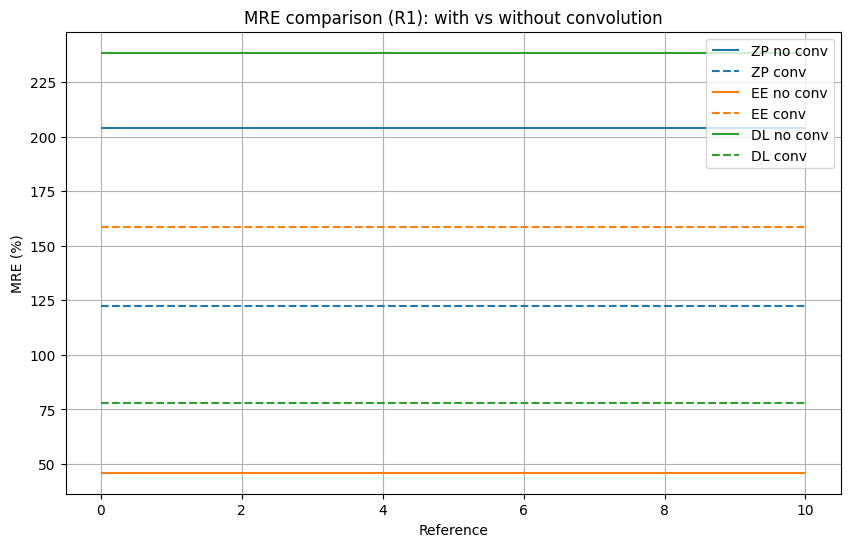

In [99]:
plt.figure(figsize=(10,6))

for var in variables_common:

    # 🔵 sin convolución
    df_no = metrics_wo_noiseR1[metrics_wo_noiseR1["Variable"] == var]
    mre_no = df_no["MRE_%"].values[0]

    # 🔴 con convolución
    df_conv = metrics_wo_noise_conv_R1[metrics_wo_noise_conv_R1["Variable"] == var]
    mre_conv = df_conv["MRE_%"].values[0]

    # sin conv
    plt.hlines(
        y=mre_no,
        xmin=0,
        xmax=10,
        linestyle='-',
        color=colors[var],
        label=f"{var} no conv"
    )

    # con conv
    plt.hlines(
        y=mre_conv,
        xmin=0,
        xmax=10,
        linestyle='--',
        color=colors[var],
        label=f"{var} conv"
    )

plt.xlabel("Reference")
plt.ylabel("MRE (%)")
plt.title("MRE comparison (R1): with vs without convolution")
plt.legend()
plt.grid(True)

plt.show()

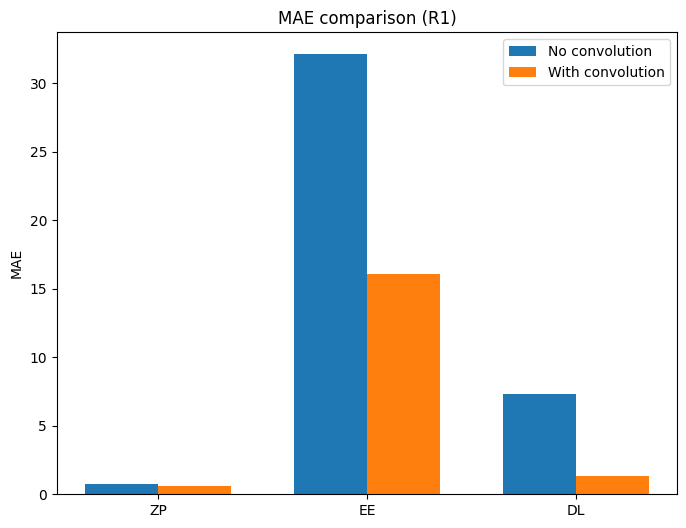

In [100]:
import numpy as np

variables_common = ['ZP', 'EE', 'DL']
x = np.arange(len(variables_common))

mae_no = []
mae_conv = []

for var in variables_common:
    mae_no.append(metrics_wo_noiseR1[metrics_wo_noiseR1["Variable"] == var]["MAE"].values[0])
    mae_conv.append(metrics_wo_noise_conv_R1[metrics_wo_noise_conv_R1["Variable"] == var]["MAE"].values[0])

width = 0.35

plt.figure(figsize=(8,6))

plt.bar(x - width/2, mae_no, width, label="No convolution")
plt.bar(x + width/2, mae_conv, width, label="With convolution")

plt.xticks(x, variables_common)
plt.ylabel("MAE")
plt.title("MAE comparison (R1)")
plt.legend()

plt.show()


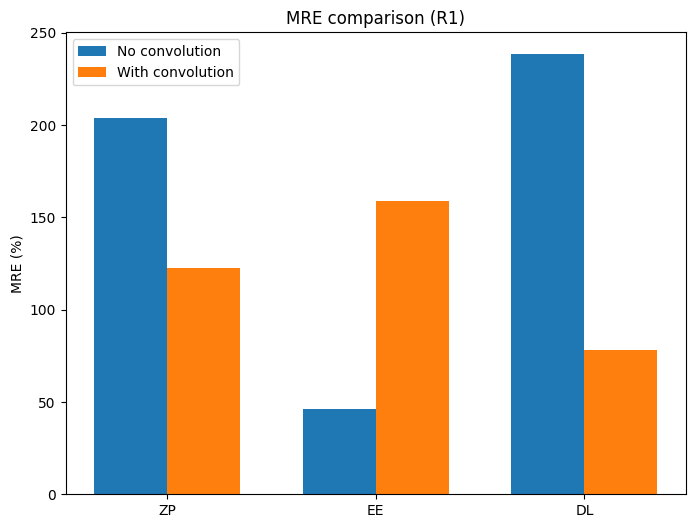

In [101]:
import numpy as np

variables_common = ['ZP', 'EE', 'DL']
x = np.arange(len(variables_common))

mae_no = []
mae_conv = []

for var in variables_common:
    mae_no.append(metrics_wo_noiseR1[metrics_wo_noiseR1["Variable"] == var]["MRE_%"].values[0])
    mae_conv.append(metrics_wo_noise_conv_R1[metrics_wo_noise_conv_R1["Variable"] == var]["MRE_%"].values[0])

width = 0.35

plt.figure(figsize=(8,6))

plt.bar(x - width/2, mae_no, width, label="No convolution")
plt.bar(x + width/2, mae_conv, width, label="With convolution")

plt.xticks(x, variables_common)
plt.ylabel("MRE (%)")
plt.title("MRE comparison (R1)")
plt.legend()

plt.show()


## Round 2

### Route to the csv file and read it

In [41]:
#Route to the file

BASE_DIR = os.getcwd()

file_path = os.path.join(
    BASE_DIR,
    "Pred_obs_R2.csv",
)

#Read the CSV file
DE_round2 = pd.read_csv(file_path, sep=";")
DE_round2 = DE_round2.dropna(how="all") # Remove rows where all values are NaN

### Metrics calculations (without "noise")

In [42]:
mae_results2 =  []
mre_results2 = []

for var in variables:
    
    y_obs = pd.to_numeric(DE_round2[f"{var}_obs"], errors='coerce')
    y_pred = pd.to_numeric(DE_round2[f"{var}_pred"], errors='coerce')

    df_temp = pd.DataFrame({"obs": y_obs, "pred": y_pred}).dropna()

    y_obs = df_temp["obs"].values
    y_pred = df_temp["pred"].values

    #MAE calculation
    mae = mean_absolute_error(y_obs, y_pred)
    
    #MRE calculation
    mre = np.mean(np.abs((y_obs - y_pred) / (np.abs(y_obs) + epsilon))) * 100

    mae_results2.append([var, mae])
    mre_results2.append([var, mre])

#Create dataframes for MAE and MRE results
mae_df2 = pd.DataFrame(mae_results2, columns=["Variable", "MAE"]).round(2)
mre_df2 = pd.DataFrame(mre_results2, columns=["Variable", "MRE_%"]).round(2)    

#Merge metrics dataframes
metrics_wo_noiseR2 = pd.merge(mae_df2, mre_df2, on="Variable"). round(2)

#### Show and print results

In [43]:
#Show results
print("\nMetrics without noise R2:")
print(metrics_wo_noiseR2)

# Save results
output_path = os.path.join(BASE_DIR, "Metrics_wo_noiseR2.csv")
metrics_wo_noiseR2.to_csv(output_path, index=False)


Metrics without noise R2:
  Variable    MAE         MRE_%
0     Size  65.68  1.296400e+02
1      PdI   0.12  4.324000e+01
2       ZP   0.80  5.745600e+02
3       EE  55.10  2.040667e+11
4       DL  11.19  2.353333e+10


### Metrics calculations (with "noise" *Monte Carlo*)

In [53]:
mae_noise_results2 = []
mre_noise_results2 = []

for sigma_factor in sigmas:
    
    for var in variables:

        #Convert data to numeric and drop NaN values  
        y_obs = pd.to_numeric(DE_round2[f"{var}_obs"], errors='coerce')
        y_pred = pd.to_numeric(DE_round2[f"{var}_pred"], errors='coerce')

        df_temp = pd.DataFrame({"obs": y_obs, "pred": y_pred}).dropna()

        y_obs = df_temp["obs"].values
        y_pred = df_temp["pred"].values

        sigma = sigma_factor * np.mean(np.abs(y_obs))

        mae_list = []
        mre_list = [] 

        #Monte Carlo simulation
        for i in range(n_iterations):

            noise = np.random.normal(0, sigma, size=len(y_obs))
            y_noisy = y_obs + noise

            #MAE
            mae = mean_absolute_error(y_noisy, y_pred)
            mae_list.append(mae)

            # MRE (%)
            mre = np.mean(np.abs((y_noisy - y_pred) / (np.abs(y_noisy) + epsilon))) * 100
            mre_list.append(mre)

        mae_noise_results2.append([
            var, #analyzed variable
            sigma_factor, #noise level
            np.mean(mae_list), #Mean MAE
            np.std(mae_list) #Standard deviation of MAE
        ])

        mre_noise_results2.append([
            var, #analyzed variable
            sigma_factor, #noise level
            np.mean(mre_list), #Mean MRE
            np.std(mre_list)  #Standard deviation of MRE
        ])

#Create dataframes for MAE and MRE results with noise
##MAE dataframe
mae_noise_df = pd.DataFrame(
    mae_noise_results2,
    columns=["Variable", "Sigma_%", "MAE_mean", "MAE_std"]
).round(2)

##MRE dataframe
mre_noise_df = pd.DataFrame(
    mre_noise_results2,
    columns=["Variable", "Sigma_%", "MRE_mean", "MRE_std"]
).round(2)


#Show the sigma results in percentage format
mae_noise_df["Sigma_%"] = (mae_noise_df["Sigma_%"] * 100).astype(int)
mre_noise_df["Sigma_%"] = (mre_noise_df["Sigma_%"] * 100).astype(int)

#Merge MAE and MRE dataframes
metrics_noiseR2 = pd.merge(mae_noise_df, mre_noise_df, on=["Variable", "Sigma_%"])

#### Show and print results

In [54]:
print("\nMetrics with noise R2 (different levels):")
print(metrics_noiseR2)

output_path = os.path.join(BASE_DIR, "Metrics_noise_R2.csv")
metrics_noiseR2.to_csv(output_path, index=False)


Metrics with noise R2 (different levels):
   Variable  Sigma_%  MAE_mean  MAE_std  MRE_mean    MRE_std
0      Size        2     65.71     0.34    130.33       4.93
1       PdI        2      0.12     0.00     43.24       1.23
2        ZP        2      0.80     0.00    574.34       7.41
3        EE        2     55.12     0.30   7641.81   12935.88
4        DL        2     11.19     0.01  67360.62  194561.42
5      Size        5     65.68     0.83    132.39      12.46
6       PdI        5      0.12     0.00     44.72       3.64
7        ZP        5      0.80     0.00    577.95      18.16
8        EE        5     55.04     0.83   4394.37   14166.21
9        DL        5     11.19     0.02  44215.85  259359.59
10     Size       10     65.91     1.84    142.89      35.33
11      PdI       10      0.12     0.00     66.53     134.89
12       ZP       10      0.80     0.00    594.08     105.16
13       EE       10     55.36     1.59   4569.12   23151.33
14       DL       10     11.20     0.03  1

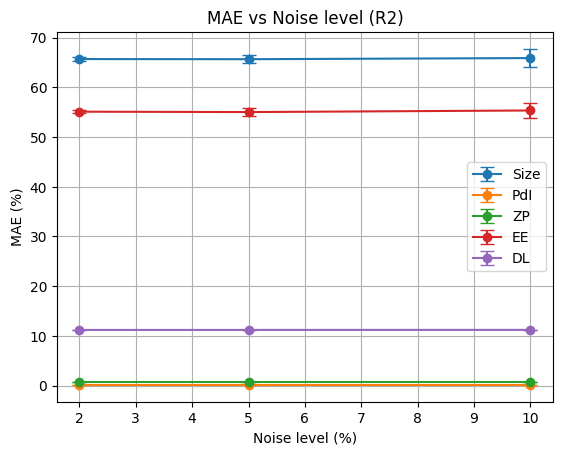

In [55]:
for var in variables:
    df_plot = metrics_noiseR2[metrics_noiseR2["Variable"] == var]

    plt.errorbar(
        df_plot["Sigma_%"],
        df_plot["MAE_mean"],
        yerr=df_plot["MAE_std"],
        marker='o',
        capsize=5,
        label=var
    )

plt.xlabel("Noise level (%)")
plt.ylabel("MAE (%)")
plt.title("MAE vs Noise level (R2)")
plt.legend()
plt.grid(True)
plt.show()

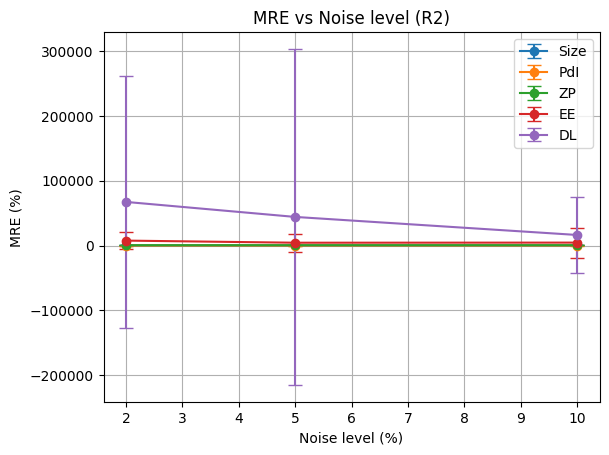

In [56]:
for var in variables:
    df_plot = metrics_noiseR2[metrics_noiseR2["Variable"] == var]

    plt.errorbar(
        df_plot["Sigma_%"],
        df_plot["MRE_mean"],
        yerr=df_plot["MRE_std"],
        marker='o',
        capsize=5,
        label=var
    )

plt.xlabel("Noise level (%)")
plt.ylabel("MRE (%)")
plt.title("MRE vs Noise level (R2)")
plt.legend()
plt.grid(True)
plt.show()

# Comparation R1 vs R2

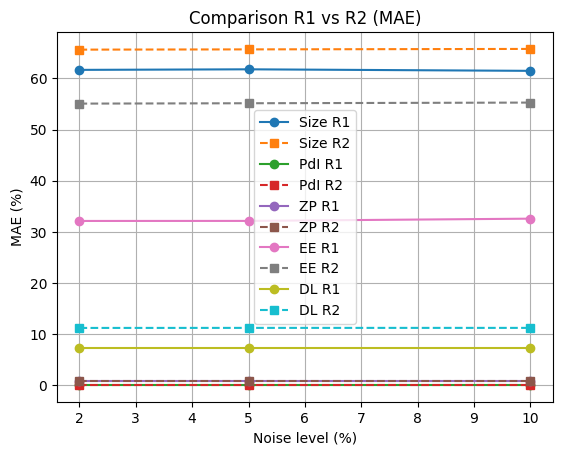

In [62]:
for var in variables:
    df_R1 = metrics_noiseR1[metrics_noiseR1["Variable"] == var]
    df_R2 = metrics_noiserR2[metrics_noiserR2["Variable"] == var]

    plt.plot(df_R1["Sigma_%"], df_R1["MAE_mean"], marker='o', label=f"{var} R1")
    plt.plot(df_R2["Sigma_%"], df_R2["MAE_mean"], marker='s', linestyle='--', label=f"{var} R2")

plt.xlabel("Noise level (%)")
plt.ylabel("MAE (%)")
plt.title("Comparison R1 vs R2 (MAE)")
plt.legend(loc='best')
plt.grid(True)
plt.show()

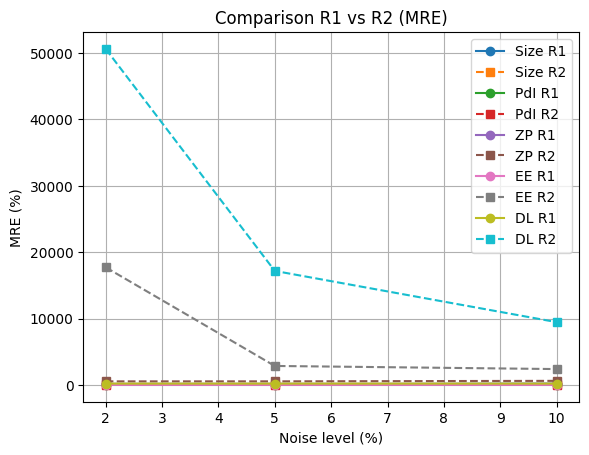

In [59]:
for var in variables:
    df_R1 = metrics_noiseR1[metrics_noiseR1["Variable"] == var]
    df_R2 = metrics_noiserR2[metrics_noiserR2["Variable"] == var]

    plt.plot(df_R1["Sigma_%"], df_R1["MRE_mean"], marker='o', label=f"{var} R1")
    plt.plot(df_R2["Sigma_%"], df_R2["MRE_mean"], marker='s', linestyle='--', label=f"{var} R2")

plt.xlabel("Noise level (%)")
plt.ylabel("MRE (%)")
plt.title("Comparison R1 vs R2 (MRE)")
plt.legend()
plt.grid(True)
plt.show()